In [120]:
import pandas as pd

resale_path = '/home/deep/property_stats/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv'


df = pd.read_csv(resale_path)
#df['year'] = [int(month.split('-')[0]) for month in df['month'] ]
#df['month'] = [int(month.split('-')[1]) for month in df['month'] ]
df['year-month'] = [int(month.split('-')[0]+month.split('-')[1]) for month in df['month'] ]
df['storey_min'] = [int(storey.split(' TO ')[0]) for storey in df['storey_range']]

df['remaining_lease_years'] = [int(lease.split(' years')[0]) for lease in df['remaining_lease']]

q_dict = {'01':'Q1','02':'Q1','03':'Q1',
          '04':'Q2','05':'Q2','06':'Q2',
          '07':'Q3','08':'Q3','09':'Q3',
          '10':'Q4','11':'Q4','12':'Q4' }
df['quartile'] = [mth.split('-')[0]+'-'+q_dict[mth.split('-')[1]] for mth in df['month']]

df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year-month,storey_min,remaining_lease_years,quartile
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,201701,10,61,2017-Q1
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,201701,1,60,2017-Q1
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,201701,1,62,2017-Q1
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,201701,4,62,2017-Q1
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,201701,1,62,2017-Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228220,2026-03,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,60 years 06 months,835000.0,202603,10,60,2026-Q1
228221,2026-03,YISHUN,EXECUTIVE,611,YISHUN ST 61,07 TO 09,146.0,Maisonette,1987,60 years 09 months,888000.0,202603,7,60,2026-Q1
228222,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,10 TO 12,142.0,Apartment,1987,60 years 10 months,980000.0,202603,10,60,2026-Q1
228223,2026-03,YISHUN,EXECUTIVE,836,YISHUN ST 81,10 TO 12,146.0,Maisonette,1988,61 years,995000.0,202603,10,61,2026-Q1


In [130]:
df[['pungg' in word.lower() for word in df['street_name']]]['street_name'].unique()

<StringArray>
[     'PUNGGOL FIELD', 'PUNGGOL FIELD WALK',         'PUNGGOL RD',
       'PUNGGOL EAST',         'PUNGGOL DR',       'PUNGGOL CTRL',
         'PUNGGOL PL',       'PUNGGOL WALK',        'PUNGGOL WAY']
Length: 9, dtype: str

In [67]:
df['town'].unique()

<StringArray>
[     'ANG MO KIO',           'BEDOK',          'BISHAN',     'BUKIT BATOK',
     'BUKIT MERAH',   'BUKIT PANJANG',     'BUKIT TIMAH',    'CENTRAL AREA',
   'CHOA CHU KANG',        'CLEMENTI',         'GEYLANG',         'HOUGANG',
     'JURONG EAST',     'JURONG WEST', 'KALLANG/WHAMPOA',   'MARINE PARADE',
       'PASIR RIS',         'PUNGGOL',      'QUEENSTOWN',       'SEMBAWANG',
        'SENGKANG',       'SERANGOON',        'TAMPINES',       'TOA PAYOH',
       'WOODLANDS',          'YISHUN']
Length: 26, dtype: str

In [189]:
year_select_from = '2021'
month_select_from = '01'

#street_name_select = 'COMPASSVALE BOW'
street_name_select = 'PUNGGOL WALK'
#town_select = 'ANG MO KIO'

storey_range_from = 7

floor_area_from = 90

lease_commence_date_from = 2010

flat_type_select = '4 ROOM' #'2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', '1 ROOM', 'MULTI-GENERATION'


In [190]:
df_select = df[(df['year-month'] > int(year_select_from+month_select_from)) & (df['street_name'] == street_name_select.upper()) &
               (df['floor_area_sqm'] > floor_area_from) & (df['lease_commence_date'] > lease_commence_date_from) &
               (df['flat_type'] == flat_type_select) & (df['storey_min'] >= storey_range_from)]
df_select


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year-month,storey_min,remaining_lease_years,quartile
91347,2021-02,PUNGGOL,4 ROOM,310A,PUNGGOL WALK,13 TO 15,92.0,Premium Apartment,2016,94 years 05 months,510000.0,202102,13,94,2021-Q1
91360,2021-02,PUNGGOL,4 ROOM,308B,PUNGGOL WALK,07 TO 09,92.0,Premium Apartment,2016,94 years 02 months,525000.0,202102,7,94,2021-Q1
91363,2021-02,PUNGGOL,4 ROOM,310B,PUNGGOL WALK,10 TO 12,92.0,Premium Apartment,2016,94 years 05 months,528000.0,202102,10,94,2021-Q1
91369,2021-02,PUNGGOL,4 ROOM,310C,PUNGGOL WALK,16 TO 18,92.0,Premium Apartment,2016,94 years 05 months,535000.0,202102,16,94,2021-Q1
91371,2021-02,PUNGGOL,4 ROOM,271D,PUNGGOL WALK,13 TO 15,93.0,Premium Apartment,2014,92 years 03 months,535000.0,202102,13,92,2021-Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225550,2026-03,PUNGGOL,4 ROOM,310A,PUNGGOL WALK,10 TO 12,92.0,Premium Apartment,2016,89 years 04 months,718000.0,202603,10,89,2026-Q1
225554,2026-03,PUNGGOL,4 ROOM,212B,PUNGGOL WALK,13 TO 15,93.0,Model A,2015,88 years 02 months,650000.0,202603,13,88,2026-Q1
225555,2026-03,PUNGGOL,4 ROOM,310B,PUNGGOL WALK,07 TO 09,92.0,Premium Apartment,2016,89 years 04 months,693000.0,202603,7,89,2026-Q1
225556,2026-03,PUNGGOL,4 ROOM,271D,PUNGGOL WALK,07 TO 09,94.0,Premium Apartment,2014,87 years 02 months,780000.0,202603,7,87,2026-Q1


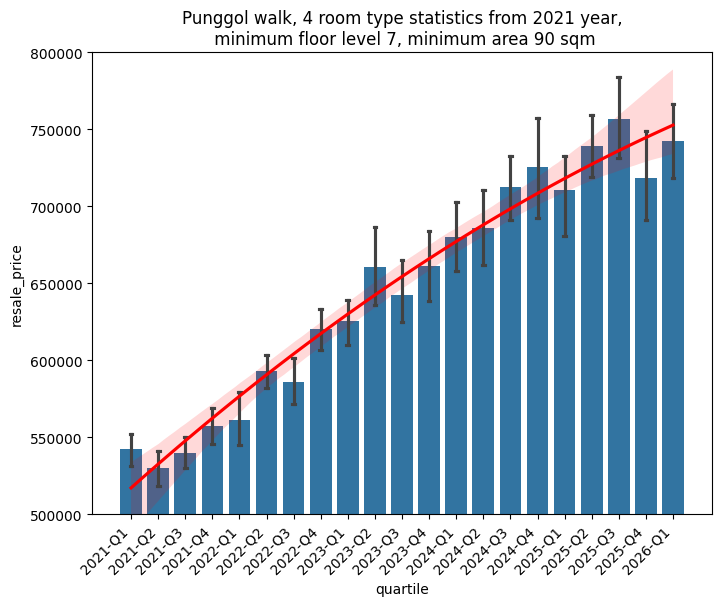

In [194]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

#stat_quantile = ['month', 12] # month
stat_quantile = ['quartile', 4] # quartile

df_aggr = df_select.groupby(by = [stat_quantile[0]])['resale_price'].mean()

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(data=df_select, x=stat_quantile[0], y="resale_price", ax=ax, capsize=0.1)#, hue="group_column")
#sns.lineplot(x='month', y='resale_price', data=df_select, ax=ax, color='red', marker='o')
sns.regplot(x=np.arange(len(df_aggr)), y=df_aggr, ax=ax, scatter=False,color='red', order=2)

ax.set_ylim(500000, 800000)
ax.set_title(f'{street_name_select.capitalize()}, {flat_type_select.lower()} type statistics from {year_select_from} year,\n minimum floor level {storey_range_from}, minimum area {floor_area_from} sqm')

plt.xticks(rotation=45, ha='right');

In [192]:
### regression model fit

#coeff_a, coeff_b, coeff_c, coeff_d = np.polyfit(np.arange(len(df_aggr)), df_aggr, 3)
#coeff_a, coeff_b, coeff_c = np.polyfit(np.arange(len(df_aggr)), df_aggr, 2)
coeff_a, coeff_b = np.polyfit(np.arange(len(df_aggr)), df_aggr, 1) 



term = {0: int(year_select_from),
        len(df_aggr)-1: int(int(year_select_from)+(len(df_aggr)-1)/stat_quantile[1]),
        len(df_aggr)-1 + 5*stat_quantile[1]: int(int(year_select_from)+(len(df_aggr)-1 + 5*stat_quantile[1])/stat_quantile[1])}

trend = {}

for i_x, x in enumerate(term.keys()):
    
    year = term[x]
    trend[year] = coeff_a*x + coeff_b
    #trend[year] = coeff_a*x*x + coeff_b*x + coeff_c
    #trend[year] = coeff_a*x*x*x + coeff_b*x*x + coeff_c*x + coeff_d
    print(f'Year {term[x]} linear regression fit price: {int(trend[term[x]])}')
    if x != 0:
        change_pc = trend[year] / trend[term[list(term.keys())[i_x-1]]]
        print(f'   Change from previous period ({year}/{term[list(term.keys())[i_x-1]]}): {int(change_pc*100)}%')
    print('\n')

Year 2021 linear regression fit price: 529408


Year 2026 linear regression fit price: 764992
   Change from previous period (2026/2021): 144%


Year 2031 linear regression fit price: 1000576
   Change from previous period (2031/2026): 130%


